#Install Packages AND RESTART colab after install

In [1]:
!pip install torch==2.2.0+cu118 torchvision==0.17.0+cu118 torchaudio==2.2.0  pytorch-lightning==1.2.2  torchtext==0.6.0 -f https://download.pytorch.org/whl/torch_stable.html

!pip install scipy==1.5.4
!pip install numpy==1.26.4
!pip install tqdm
!pip install pytorch-fid==0.2.0
!pip install pandas==1.1.5
!pip install lpips==0.1.4
!pip install lmdb==1.2.1
!pip install ftfy
!pip install regex
!pip install dlib requests
!pip install gdown

Looking in links: https://download.pytorch.org/whl/torch_stable.html
  Using cached scipy-1.5.4.tar.gz (25.2 MB)
  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Installing build dependencies ... error
error: subprocess-exited-with-error

× pip subprocess to install build dependencies did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
  Using cached pandas-1.1.5.tar.gz (5.2 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to buil

## Clone github and get Checkpoints

In [2]:
!git clone https://github.com/JanParlesak/Bayes_Image_NAM
!git pull https://github.com/JanParlesak/Bayes_Image_NAM



%cd 'Bayes_Image_NAM'

Cloning into 'Bayes_Image_NAM'...
remote: Enumerating objects: 250, done.
remote: Counting objects: 100% (250/250), done.
remote: Compressing objects: 100% (188/188), done.
remote: Total 250 (delta 105), reused 176 (delta 53), pack-reused 0 (from 0)
Receiving objects: 100% (250/250), 11.06 MiB | 21.24 MiB/s, done.
Resolving deltas: 100% (105/105), done.
fatal: not a git repository (or any of the parent directories): .git
/content/Bayes_Image_NAM


# Download data and checkpoints from this [link](https://drive.google.com/file/d/13QHJIdS5z9fCON_iA7NWhqq8Ioah4M-8/view?usp=sharing).

In [3]:
!gdown --id 13QHJIdS5z9fCON_iA7NWhqq8Ioah4M-8

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=13QHJIdS5z9fCON_iA7NWhqq8Ioah4M-8
From (redirected): https://drive.google.com/uc?id=13QHJIdS5z9fCON_iA7NWhqq8Ioah4M-8&confirm=t&uuid=4152d953-669f-4ed5-b956-94136d8e96b1
To: /content/Bayes_Image_NAM/ckpts_and_data.zip
100% 4.95G/4.95G [00:39<00:00, 127MB/s]


In [4]:
!unzip ckpts_and_data.zip

Archive:  ckpts_and_data.zip
   creating: ckpts and data/
  inflating: ckpts and data/checkpoint_icu_bnaim.pt  
  inflating: ckpts and data/last.ckpt  
   creating: ckpts and data/cxr_images_ny/
  inflating: ckpts and data/cxr_images_ny/A947413.png  
  inflating: ckpts and data/cxr_images_ny/A922673.png  
  inflating: ckpts and data/cxr_images_ny/A953168.png  
  inflating: ckpts and data/cxr_images_ny/A925839.png  
  inflating: ckpts and data/cxr_images_ny/A951435.png  
  inflating: ckpts and data/cxr_images_ny/A963675.png  
  inflating: ckpts and data/cxr_images_ny/A919264.png  
  inflating: ckpts and data/cxr_images_ny/A978928.png  
  inflating: ckpts and data/cxr_images_ny/A950017.png  
  inflating: ckpts and data/cxr_images_ny/A974169.png  
  inflating: ckpts and data/cxr_images_ny/A962942.png  
  inflating: ckpts and data/cxr_images_ny/A997729.png  
  inflating: ckpts and data/cxr_images_ny/A952677.png  
  inflating: ckpts and data/cxr_images_ny/A948013.png  
  inflating: ckpts an

In [5]:
import os
import os.path as osp

weight_dir_path = f'/content/Bayes_Image_NAM/diffae/checkpoints/'
if not osp.exists(weight_dir_path): os.makedirs(weight_dir_path)

!mv "/content/Bayes_Image_NAM/ckpts and data/last.ckpt" "/content/Bayes_Image_NAM/diffae/checkpoints/"

In [8]:
%cd 'diffae'

/content/Bayes_Image_NAM/diffae


## Load pretrained diffusion autoencoder

In [9]:
from templates import *

In [11]:
device = 'cuda'
model_config = cxr128_autoenc_130M()

print(model_config.name)

device = 'cuda'
conf = cxr128_autoenc_130M()

pretrained_encoder = LitModel(conf)
state = torch.load(f'/content/Bayes_Image_NAM/diffae/checkpoints/last.ckpt', map_location='cpu', weights_only=False)
pretrained_encoder.load_state_dict(state['state_dict'], strict=False)
pretrained_encoder.ema_model.eval()
pretrained_encoder.ema_model.to(device);

Global seed set to 0
INFO:lightning:Global seed set to 0


cxr128_autoenc_130M
Model params: 122.59 M


## Evaluation of all three models

In [12]:
%cd '../'

/content/Bayes_Image_NAM


In [13]:
from evals import *

In [ ]:
from helpers_data import *
from configs import *
from metrics import *
from helpers import *

In [ ]:
from sklearn.metrics import (
    precision_recall_curve,
    auc,
    balanced_accuracy_score,
    roc_curve,
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score, # Import the the metrics
)

In [14]:
#@title Specify directories
root_dir = '/content/Bayes_Image_NAM/ckpts and data/cxr_images_ny'
data_dir = '/content/Bayes_Image_NAM/ckpts and data/patient_data.csv'

In [15]:
_, pre_curve_bnaim_mortality, re_curve_bnaim_mortality, targets_bnaim_mortality, pred_bnaim_mortality = test_predictions_bnaim(config = config_bnaim_mortality, ckpt_path = '/content/Bayes_Image_NAM/ckpts and data/checkpoint_mortality_bnaim.pt', root_dir = root_dir, data_dir = data_dir)
bnam_metrics_mortality, pre_curve_bnam_mortality, re_curve_bnam_mortality, targets_bnam_mortality, pred_bnam_mortality = test_predictions_bnam(config = config_mortality_bnam, ckpt_path = '/content/Bayes_Image_NAM/ckpts and data/bnam_mortality_checkpoint.pt', root_dir = root_dir, data_dir = data_dir)
_ , pre_curve_nam_mortality, re_curve_nam_mortality, targets_nam_mortality, pred_nam_mortality = test_predictions_nam(config = config_mortality_nam, ckpt_path = '/content/Bayes_Image_NAM/ckpts and data/checkpoint_mortality_nam.pt', root_dir = root_dir, data_dir = data_dir)

Global seed set to 0
INFO:lightning:Global seed set to 0


cxr128_autoenc_130M
Model params: 122.59 M


In [18]:
_, pre_curve_bnaim_ventilation, re_curve_bnaim_ventilation, targets_bnaim_ventilation, pred_bnaim_ventilation = test_predictions_bnaim(config = config_ventilated_bnaim, ckpt_path = '/content/Bayes_Image_NAM/ckpts and data/checkpoint_ventilated_bnaim.pt', root_dir = root_dir, data_dir = data_dir)
_, pre_curve_bnam_ventilation, re_curve_bnam_ventilation, targets_bnam_ventilation, pred_bnam_ventilation = test_predictions_bnam(config = config_ventilated_bnam, ckpt_path = '/content/Bayes_Image_NAM/ckpts and data/bnam_ventilation_checkpoint.pt', root_dir = root_dir, data_dir = data_dir)
_, pre_curve_nam_ventilation, re_curve_nam_ventilation, targets_nam_ventilation, pred_nam_ventilation = test_predictions_nam(config = config_ventilated_nam, ckpt_path = '/content/Bayes_Image_NAM/ckpts and data/checkpoint_ventilated_nam.pt', root_dir = root_dir, data_dir = data_dir)


Global seed set to 0
INFO:lightning:Global seed set to 0


cxr128_autoenc_130M
Model params: 122.59 M


In [19]:
_, pre_curve_bnaim_icu, re_curve_bnaim_icu, targets_bnaim_icu, pred_bnaim_icu = test_predictions_bnaim(config = config_icu_bnaim, ckpt_path = '/content/Bayes_Image_NAM/ckpts and data/checkpoint_icu_bnaim.pt', root_dir = root_dir, data_dir = data_dir)
_, pre_curve_bnam_icu, re_curve_bnam_icu, targets_bnam_icu, pred_bnam_icu = test_predictions_bnam(config = config_icu_bnam, ckpt_path = '/content/Bayes_Image_NAM/ckpts and data/bnam_icu_checkpoint.pt', root_dir = root_dir, data_dir = data_dir)
_, pre_curve_nam_icu, re_curve_nam_icu, targets_nam_icu, pred_nam_icu = test_predictions_nam(config = config_icu_nam, ckpt_path = '/content/Bayes_Image_NAM/ckpts and data/checkpoint_icu_nam.pt', root_dir = root_dir, data_dir = data_dir)

Global seed set to 0
INFO:lightning:Global seed set to 0


cxr128_autoenc_130M
Model params: 122.59 M


## Plot PR-Curves


In [20]:
prev_mort = np.mean(targets_bnaim_mortality.numpy())
prev_vent = np.mean(targets_bnaim_ventilation.numpy())
prev_icu = np.mean(targets_bnaim_icu.numpy())

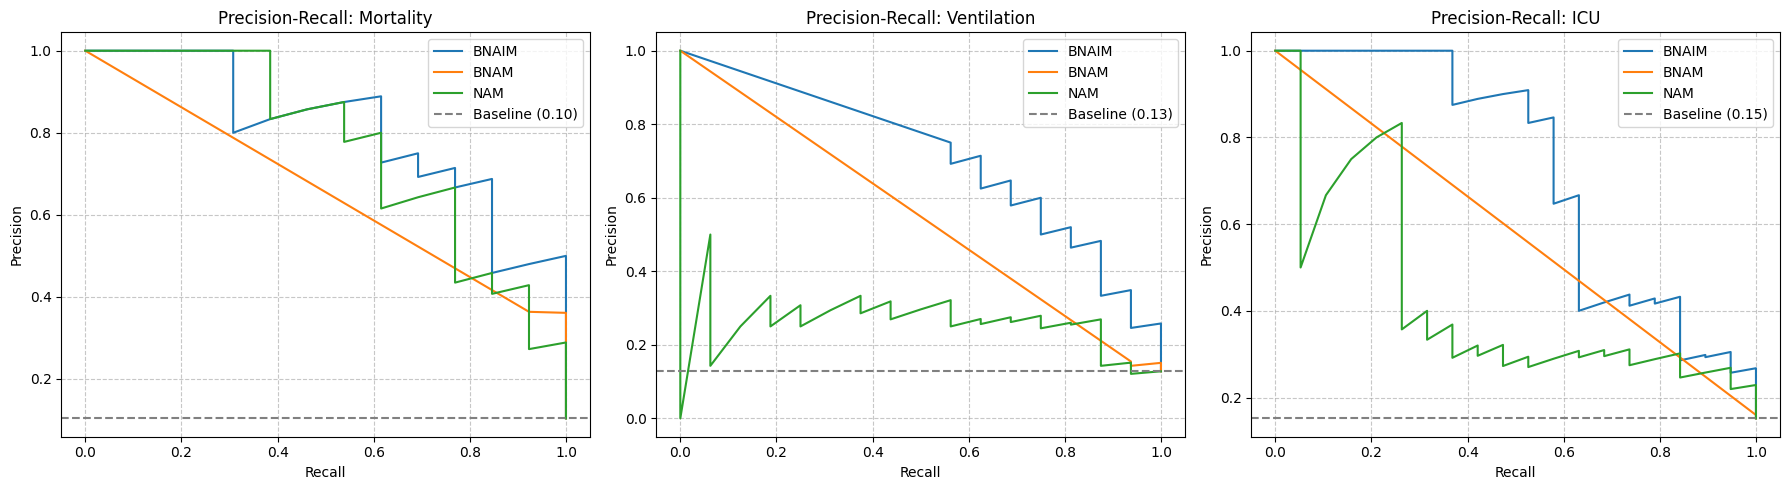

In [21]:
import matplotlib.pyplot as plt

# Set up the figure and axes (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1. Mortality Plot ---
axes[0].plot(re_curve_bnaim_mortality, pre_curve_bnaim_mortality, label='BNAIM')
axes[0].plot(re_curve_bnam_mortality, pre_curve_bnam_mortality, label='BNAM')
axes[0].plot(re_curve_nam_mortality, pre_curve_nam_mortality, label='NAM')
axes[0].axhline(y=prev_mort, color='gray', linestyle='--', label=f'Baseline ({prev_mort:.2f})')
axes[0].set_title('Precision-Recall: Mortality')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# --- 2. Ventilation Plot ---
axes[1].plot(re_curve_bnaim_ventilation, pre_curve_bnaim_ventilation, label='BNAIM')
axes[1].plot(re_curve_bnam_ventilation, pre_curve_bnam_ventilation, label='BNAM')
axes[1].plot(re_curve_nam_ventilation, pre_curve_nam_ventilation, label='NAM')
axes[1].axhline(y=prev_vent, color='gray', linestyle='--', label=f'Baseline ({prev_vent:.2f})')
axes[1].set_title('Precision-Recall: Ventilation')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

# --- 3. ICU Plot ---
axes[2].plot(re_curve_bnaim_icu, pre_curve_bnaim_icu, label='BNAIM')
axes[2].plot(re_curve_bnam_icu, pre_curve_bnam_icu, label='BNAM')
axes[2].plot(re_curve_nam_icu, pre_curve_nam_icu, label='NAM')
axes[2].axhline(y=prev_icu, color='gray', linestyle='--', label=f'Baseline ({prev_icu:.2f})')
axes[2].set_title('Precision-Recall: ICU')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.7)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

## Plot Calibration-Curves

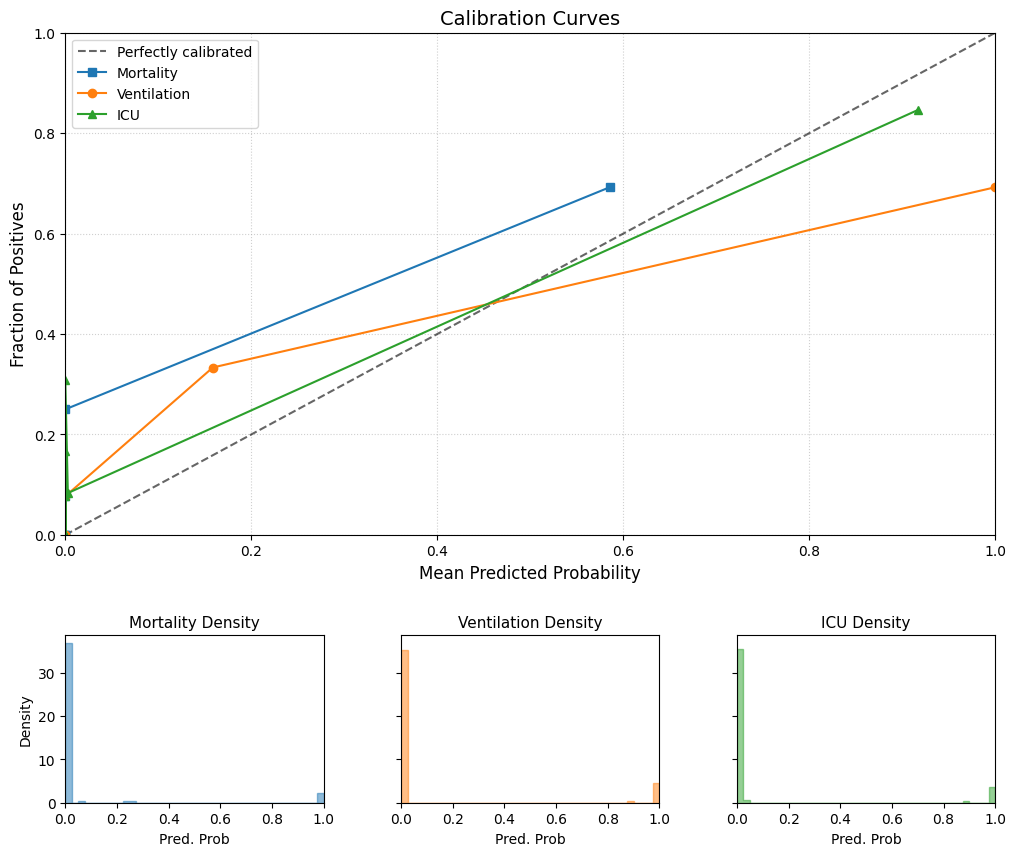

In [24]:
import matplotlib.gridspec as gridspec
from sklearn.calibration import calibration_curve

# 1. Calculate calibration curves (using quantile strategy)
BINS = 10
f_mort, m_mort = calibration_curve(targets_bnaim_mortality, pred_bnaim_mortality, n_bins=BINS, strategy='quantile')
f_vent, m_vent = calibration_curve(targets_bnaim_ventilation, pred_bnaim_ventilation, n_bins=BINS, strategy='quantile')
f_icu, m_icu = calibration_curve(targets_bnaim_icu, pred_bnaim_icu, n_bins=BINS, strategy='quantile')

# 2. Setup the figure and GridSpec (2 rows, 3 columns)
fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(2, 3, height_ratios=[3, 1], hspace=0.3, wspace=0.3)

# --- TOP PLOT: Combined Calibration Curves ---
ax_main = fig.add_subplot(gs[0, :]) # Spans all 3 columns in the top row

ax_main.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated", alpha=0.6)
ax_main.plot(m_mort, f_mort, "s-", color='C0', label="Mortality", markersize=6)
ax_main.plot(m_vent, f_vent, "o-", color='C1', label="Ventilation", markersize=6)
ax_main.plot(m_icu, f_icu, "^-", color='C2', label="ICU", markersize=6)

ax_main.set_xlabel("Mean Predicted Probability", fontsize=12)
ax_main.set_ylabel("Fraction of Positives", fontsize=12)
ax_main.set_title("Calibration Curves", fontsize=14)
ax_main.set_xlim([0, 1])
ax_main.set_ylim([0, 1])
ax_main.legend(loc="upper left")
ax_main.grid(True, linestyle=':', alpha=0.6)

# --- BOTTOM PLOTS: Individual Densities ---
# Using shared Y-axis so densities are comparable across plots
ax_dens1 = fig.add_subplot(gs[1, 0])
ax_dens2 = fig.add_subplot(gs[1, 1], sharey=ax_dens1)
ax_dens3 = fig.add_subplot(gs[1, 2], sharey=ax_dens1)

dens_axes = [ax_dens1, ax_dens2, ax_dens3]
preds = [pred_bnaim_mortality, pred_bnaim_ventilation, pred_bnaim_icu]
titles = ["Mortality Density", "Ventilation Density", "ICU Density"]
colors = ['C0', 'C1', 'C2']

for ax, pred, title, color in zip(dens_axes, preds, titles, colors):
    ax.hist(pred, bins=40, range=(0, 1), density=True,
            color=color, alpha=0.5, histtype='stepfilled', edgecolor=color)
    ax.set_title(title, fontsize=11)
    ax.set_xlim([0, 1])
    ax.set_xlabel("Pred. Prob")
    if ax == ax_dens1:
        ax.set_ylabel("Density")
    else:
        plt.setp(ax.get_yticklabels(), visible=False) # Hide Y labels for inner plots

plt.show()

## Define functions


In [25]:
def get_feature_predictions(model, features, n_samples): #add mean bayesian here
    model = model.to(device)
    feature_predictions = []
    output_lis = []
    unique_features = compute_features(features)
    #print(unique_features)
    for c, i in enumerate(unique_features):
        output_mc = []
        for sample in range(n_samples):
          f_preds, _ = model.bayes_feat_nam.feature_nns[c](torch.tensor(i).to(device))
          output_mc.append(f_preds)

        output = torch.stack(output_mc)
        output_lis.append(output.detach().cpu().numpy())
    feature_predictions = output_lis

    return feature_predictions

def compute_features(features):
  x_data = features
  single_features = np.split(x_data, x_data.shape[1], axis=1)
  #print(len(single_features[13]))
  unique_features = [np.unique(f, axis=0) for f in single_features]
  return unique_features


def inverse_min_max_scaler(x, min_val, max_val):
  return (x + 1)/2 * (max_val - min_val) + min_val


def compute_mean_feature_importance(avg_hist_data,n_samples):
  mean_abs_score = {}
  std_score = {}
  mean = []

  for k in avg_hist_data:
    for j in range(n_samples):
      mean.append(np.mean(np.abs(avg_hist_data[k][j] - MEAN_PRED[k][j])))
    mean_abs_score[k]= np.mean(mean)
    std_score[k] = np.std(mean)
    mean = []
  x1, x2 = zip(*mean_abs_score.items())
  return x1, x2, std_score

def plot_mean_feature_importance(x1, x2, std_score, width = 0.3):
  fig = plt.figure(figsize=(5, 4))
  ind = np.arange(len(x1))  # the x locations for the groups
  x1_indices = np.argsort(x2)
  cols_here = [cols[i] for i in x1_indices]
  # x1_here = [x12[i] for i in x1_indices]
  x2_here = [x2[i] for i in x1_indices]
  std_score = list(std_score.values())
  std = [std_score[i] for i in x1_indices]

  plt.bar(ind, x2_here, width, yerr = std, capsize=5, label='NAMs')
  # plt.bar(ind+width, x1_here, width, label='EBMs')
  plt.xticks(ind + width/2, cols_here, rotation=90, fontsize='large')
  plt.ylabel('Mean Absolute Score', fontsize='x-large')
  plt.legend(loc='upper right', fontsize='large')
  plt.title(f'Overall Importance: CXR_NY', fontsize='x-large')
  plt.show()
  return fig

In [26]:
import matplotlib.pyplot as plt
import seaborn
import matplotlib.patches as patches

def shade_by_density_blocks(hist_data, num_rows, num_cols,
                            n_blocks=5,
                            color='skyblue',  # CHANGED: Default color to a blue shade
                            feature_to_use=None):
    hist_data_pairs = list(hist_data.items())
    hist_data_pairs.sort(key=lambda x: x[0])


    # Calculate global y limits for consistent shading
    min_y = np.min([np.min(a[1]) for a in hist_data_pairs])
    max_y = np.max([np.max(a[1]) for a in hist_data_pairs])
    min_max_dif = max_y - min_y
    min_y = min_y - 0.01 * min_max_dif
    max_y = max_y + 0.01 * min_max_dif

    if feature_to_use:
        hist_data_pairs = [v for v in hist_data_pairs if v[0] in feature_to_use]

    for i, (name, pred) in enumerate(hist_data_pairs):
        unique_x_data = UNIQUE_FEATURES_ORIGINAL[name]
        single_feature_data = SINGLE_FEATURES_ORIGINAL[name]
        ax = plt.subplot(num_rows, num_cols, i+1)

        min_x = np.min(unique_x_data)
        max_x = np.max(unique_x_data)
        x_n_blocks = min(n_blocks, len(unique_x_data))

        if name in CATEGORICAL_NAMES:
            min_x -= 0.5
            max_x += 0.5

        segments = (max_x - min_x) / x_n_blocks
        density = np.histogram(single_feature_data, bins=x_n_blocks)
        normed_density = density[0] / np.max(density[0])

        rect_params = []
        for p in range(x_n_blocks):
            start_x = min_x + segments * p
            end_x = min_x + segments * (p + 1)
            d = min(1.0, 0.01 + normed_density[p])
            rect_params.append((d, start_x, end_x))

        for param in rect_params:
            alpha, start_x, end_x = param
            # The patches use the 'color' variable defined in the function arguments
            rect = patches.Rectangle((start_x, min_y - 1), end_x - start_x,
                                     max_y - min_y + 1, linewidth=0.01,
                                     edgecolor=color, facecolor=color, alpha=alpha, zorder=0)
            ax.add_patch(rect)


def plot_all_hist(hist_data, standard_deviations, num_rows, num_cols, y_label, y_scale=1.0, color_base='hotpink', # CHANGED: Default to pink
                  linewidth=3.0, min_y=None, max_y=None, alpha=1.0,
                  feature_to_use=None):

    hist_data_pairs = list(hist_data.items())
    hist_data_pairs.sort(key=lambda x: x[0])

    std_dict = standard_deviations

    if min_y is None:
        min_y = np.min([np.min(a) for _, a in hist_data_pairs]) * y_scale
    if max_y is None:
        max_y = np.max([np.max(a) for _, a in hist_data_pairs]) * y_scale

    min_max_dif = max_y - min_y
    min_y = min_y - 0.01 * min_max_dif
    max_y = max_y + 0.01 * min_max_dif

    col_mapping = COL_NAMES['CXR_NY']
    feature_mapping = FEATURE_LABEL_MAPPING['CXR_NY']
    total_mean_bias = 0

    if feature_to_use:
        hist_data_pairs = [v for v in hist_data_pairs if v[0] in feature_to_use]

    for i, (name, pred) in enumerate(hist_data_pairs):
        mean_pred = np.mean(list(MEAN_PRED[name].values()))
        total_mean_bias += mean_pred
        unique_x_data = UNIQUE_FEATURES_ORIGINAL[name]

        # Get the standard deviation for this specific feature
        feature_std = std_dict[name]

        # Calculate bounds (centered at the mean-adjusted prediction)
        y_center = pred - mean_pred
        upper_bound = y_center + (2 * feature_std)
        lower_bound = y_center - (2 * feature_std)

        plt.subplot(num_rows, num_cols, i+1)

        if name in CATEGORICAL_NAMES:
            unique_x_data = np.round(unique_x_data, decimals=1)
            step_loc = "mid" if len(unique_x_data) <= 2 else "post"
            unique_plot_data = np.array(unique_x_data) - 0.5
            unique_plot_data[-1] += 1

            #print(f'{name}: {unique_plot_data}, y: {y_center}, std: {feature_std}')


            # 1. Plot the Shaded SD Area for Categorical
            plt.fill_between(unique_plot_data, lower_bound.squeeze(), upper_bound.squeeze(),
                             step=step_loc, color=color_base, alpha=0.5, zorder=2)

            # 2. Plot the main line
            plt.step(unique_plot_data, y_center, color=color_base,
                     linewidth=linewidth, where=step_loc, alpha=alpha)

            if name in feature_mapping:
                labels, rot = feature_mapping[name]
            else:
                labels = unique_x_data
                rot = None
            plt.xticks(unique_x_data, labels=labels, fontsize='x-large', rotation=rot)

        else:

            # 1. Plot the Shaded SD Area for Continuous
            plt.fill_between(unique_x_data, lower_bound.squeeze(), upper_bound.squeeze(),
                             color=color_base, alpha=0.5, zorder=2)

            # 2. Plot the main line
            plt.plot(unique_x_data, y_center, color=color_base,
                     linewidth=linewidth, alpha=alpha, zorder = 3)
            plt.xticks(fontsize='x-large')

        plt.ylim(min_y, max_y)
        plt.yticks(fontsize='x-large')

        min_x = np.min(unique_x_data)
        max_x = np.max(unique_x_data)
        if name in CATEGORICAL_NAMES:
            min_x -= 0.5
            max_x += 0.5
        plt.xlim(min_x, max_x)

        if i % num_cols == 0:
            plt.ylabel(y_label, fontsize='x-large')
        plt.xlabel(col_mapping[name], fontsize='x-large')

    return min_y, max_y

In [27]:
rescale_names = ['39156-5_Body mass index (BMI) [Ratio]',
                 '76282-3_Heart rate.beat-to-beat by EKG',
                 '8480-6_Systolic blood pressure',
                 '9279-1_Respiratory rate',
                 '59408-5_Oxygen saturation in Arterial blood by Pulse oximetry',
                 '2823-3_Potassium [Moles/volume] in Serum or Plasma',
                 '2524-7_Lactate [Moles/volume] in Serum or Plasma',
                 '1988-5_C reactive protein [Mass/volume] in Serum or Plasma',
                 '2951-2_Sodium [Moles/volume] in Serum or Plasma',
                 ]

In [28]:
new_col_names = ['age.splits: (74,90]',
 'age.splits: [18,59]',
 'age.splits: (59,74]',
 'gender_concept_name',
 'smoking_status_v',
 '39156-5_Body mass index (BMI) [Ratio]',
 'htn_v',
 'dm_v',
 'ckd_v',
 'other_lung_disease_v',
 'malignancies_v',
 '76282-3_Heart rate.beat-to-beat by EKG',
 '8480-6_Systolic blood pressure',
 '9279-1_Respiratory rate',
 '59408-5_Oxygen saturation in Arterial blood by Pulse oximetry',
 '2823-3_Potassium [Moles/volume] in Serum or Plasma',
 '2524-7_Lactate [Moles/volume] in Serum or Plasma',
 '1988-5_C reactive protein [Mass/volume] in Serum or Plasma',
 '2951-2_Sodium [Moles/volume] in Serum or Plasma']

In [29]:
col_min_max = {'gender_concept_name': (0.0, 1.0),
 'smoking_status_v': (0.0, 1.0),
 '39156-5_Body mass index (BMI) [Ratio]': (11.95, 92.8),
 'htn_v': (0.0, 1.0),
 'dm_v': (0.0, 1.0),
 'ckd_v': (0.0, 1.0),
 'other_lung_disease_v': (0.0, 1.0),
 'malignancies_v': (0.0, 1.0),
 '76282-3_Heart rate.beat-to-beat by EKG': (6.0, 245.0),
 '8480-6_Systolic blood pressure': (55.0, 222.0),
 '9279-1_Respiratory rate': (11.0, 88.0),
 '59408-5_Oxygen saturation in Arterial blood by Pulse oximetry': (55.0,
  100.0),
 '2823-3_Potassium [Moles/volume] in Serum or Plasma': (2.0, 7.7),
 '2524-7_Lactate [Moles/volume] in Serum or Plasma': (0.5, 20.0),
 '1988-5_C reactive protein [Mass/volume] in Serum or Plasma': (0.1, 62.7),
 '2951-2_Sodium [Moles/volume] in Serum or Plasma': (112.0, 167.0)
 }

In [30]:
#@title Feature label mappings and column names
FEATURE_LABEL_MAPPING = {}
FEATURE_LABEL_MAPPING['CXR_NY'] = {
    'age.splits: [18,59]': (['No', 'Yes'], None),
    'age.splits: (74,90]': (['No', 'Yes'], None),
    'age.splits: (59,74]': (['No', 'Yes'], None),
    'gender_concept_name': (['Male', 'Female'], None)
    }


#@title Column Names

COL_NAMES = {}
COL_NAMES['CXR_NY'] = {
    'age.splits: [18,59]' : 'age 18-59',
    'age.splits: (74,90]': 'age 74-90',
    'age.splits: (59,74]': 'age 59-74',
    'gender_concept_name': 'Gender',
    'smoking_status_v' : 'Smoking',
    '39156-5_Body mass index (BMI) [Ratio]' : 'BMI',
    'htn_v' : 'Taking anti-hypertensive medications',
    'dm_v' : 'Diabetes',
    'ckd_v' : 'Chronic Kidney Disease',
    'other_lung_disease_v' : 'Other lung diseases',
    'malignancies_v' : 'Malignancy',
    '76282-3_Heart rate.beat-to-beat by EKG' : 'Heart Rate',
    '8480-6_Systolic blood pressure': 'Systolic Blood Pressure',
    '9279-1_Respiratory rate' : 'Respiratory Rate',
    '59408-5_Oxygen saturation in Arterial blood by Pulse oximetry' : 'Oxygen Saturation',
    '2823-3_Potassium [Moles/volume] in Serum or Plasma' : 'Potassium in Serum or Plasma',
    '2524-7_Lactate [Moles/volume] in Serum or Plasma' : 'Lactate in Serum or Plasma',
    '1988-5_C reactive protein [Mass/volume] in Serum or Plasma' : 'C-reactive Protein',
    '2951-2_Sodium [Moles/volume] in Serum or Plasma' : 'Sodium in Serum or Plasma',

  }


In [31]:
CATEGORICAL_NAMES = ['age.splits: [18,59]', 'age.splits: (74,90]', 'age.splits: (59,74]',"gender_concept_name", 'smoking_status_v', 'htn_v', 'dm_v', 'ckd_v', 'other_lung_disease_v', 'malignancies_v' ]

## Mortality


In [34]:
config = config_bnaim_mortality

_, _, test_loader, features = dataloaders_img(target_column = 'last.status', train_frac = 0.7, val_frac = 0.2, batch_size = config["batch_size"],
                                                  root_dir = root_dir, data_dir = data_dir)


best_trained_model = make_model(config, features.shape[-1])
best_trained_model.to(device)

checkpoint_path = '/content/Bayes_Image_NAM/ckpts and data/checkpoint_mortality_bnaim.pt'

model_state, _optimizer_state = torch.load(checkpoint_path)
best_trained_model.load_state_dict(model_state)

Global seed set to 0
INFO:lightning:Global seed set to 0


cxr128_autoenc_130M
Model params: 122.59 M


<All keys matched successfully>

In [35]:
feature_predictions = get_feature_predictions(best_trained_model, features, n_samples=100)

In [36]:
NUM_FEATURES = features.shape[1]
SINGLE_FEATURES = np.split(features, NUM_FEATURES, axis=1)
UNIQUE_FEATURES = [np.unique(x, axis=0) for x in SINGLE_FEATURES]

SINGLE_FEATURES_ORIGINAL = {}
UNIQUE_FEATURES_ORIGINAL = {}
for i, col in enumerate(new_col_names):
  try:
    min_val, max_val = col_min_max[col]
    UNIQUE_FEATURES_ORIGINAL[col] = inverse_min_max_scaler(
        UNIQUE_FEATURES[i][:, 0], min_val, max_val)
    SINGLE_FEATURES_ORIGINAL[col] = inverse_min_max_scaler(
        SINGLE_FEATURES[i][:, 0], min_val, max_val)
  except:
    UNIQUE_FEATURES_ORIGINAL[col] = UNIQUE_FEATURES[i][:, 0]
    SINGLE_FEATURES_ORIGINAL[col] = SINGLE_FEATURES[i][:, 0]

In [37]:
avg_hist_data = {col: predictions for col, predictions in zip(new_col_names, feature_predictions)}

In [38]:
ALL_INDICES = {}
for i, col in enumerate(new_col_names):
  x_i = features[:, i]
  ALL_INDICES[col] = np.searchsorted(UNIQUE_FEATURES[i][:, 0], x_i, 'left')

In [39]:
MEAN_PRED = {}
MEAN_STD = {}

n_samples = 100 #adjust this if fails


for col in new_col_names:
    MEAN_PRED[col] = {}
    for j in range(n_samples):
      MEAN_PRED[col][j] = np.mean([avg_hist_data[col][j][i] for i in ALL_INDICES[col]])

print(MEAN_PRED)

{'age.splits: (74,90]': {0: -7.2607737, 1: 0.50684494, 2: 1.0967647, 3: -4.1944656, 4: 1.0195528, 5: 1.0005715, 6: 6.0238256, 7: -2.4094887, 8: 1.840918, 9: 2.0757625, 10: 0.5589323, 11: 1.8929981, 12: -2.001475, 13: -7.032744, 14: 2.4411423, 15: 1.1030289, 16: -0.9763941, 17: 2.537728, 18: -4.0945992, 19: -1.4268869, 20: 0.30506822, 21: -4.1799603, 22: -1.0212383, 23: -3.0141575, 24: -0.8780709, 25: -2.6756122, 26: -2.02237, 27: -0.44639185, 28: -6.553332, 29: 0.14227407, 30: 1.8380191, 31: 0.3635109, 32: -2.5176845, 33: -2.322885, 34: -1.2015234, 35: -4.795525, 36: -0.05520099, 37: -1.9569107, 38: -6.4894648, 39: -3.9243379, 40: -3.125854, 41: 4.451293, 42: 0.44993252, 43: -3.43141, 44: 1.8000691, 45: -2.5199854, 46: 0.95155644, 47: -5.7806892, 48: -1.3475428, 49: -1.7820696, 50: 2.6214418, 51: -1.9198114, 52: -2.0488815, 53: 0.97345203, 54: -2.2166805, 55: -2.0769944, 56: 0.77537245, 57: -2.2252195, 58: -4.5034313, 59: -3.499412, 60: -2.0146284, 61: -1.4029137, 62: -0.37087965, 63: 

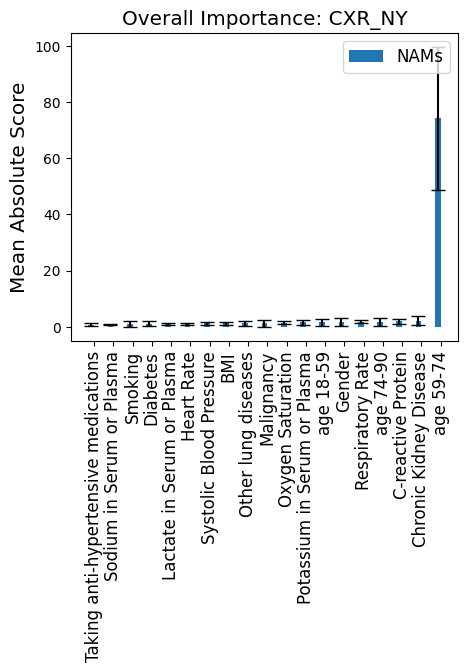

In [40]:
#@title Compute feature importance

x1, x2, std_score = compute_mean_feature_importance(avg_hist_data, n_samples=100) #add bayes and maybe images
cols = [COL_NAMES['CXR_NY'][x] for x in x1]
fig = plot_mean_feature_importance(x1, x2, std_score=std_score)

In [41]:
standard_deviations = {}
avg_hist_data_mean = {}
for key in avg_hist_data.keys():
  avg_hist_data_mean[key] = np.mean(avg_hist_data[key], axis = 0)
  standard_deviations[key] = np.std(avg_hist_data[key], axis = 0)

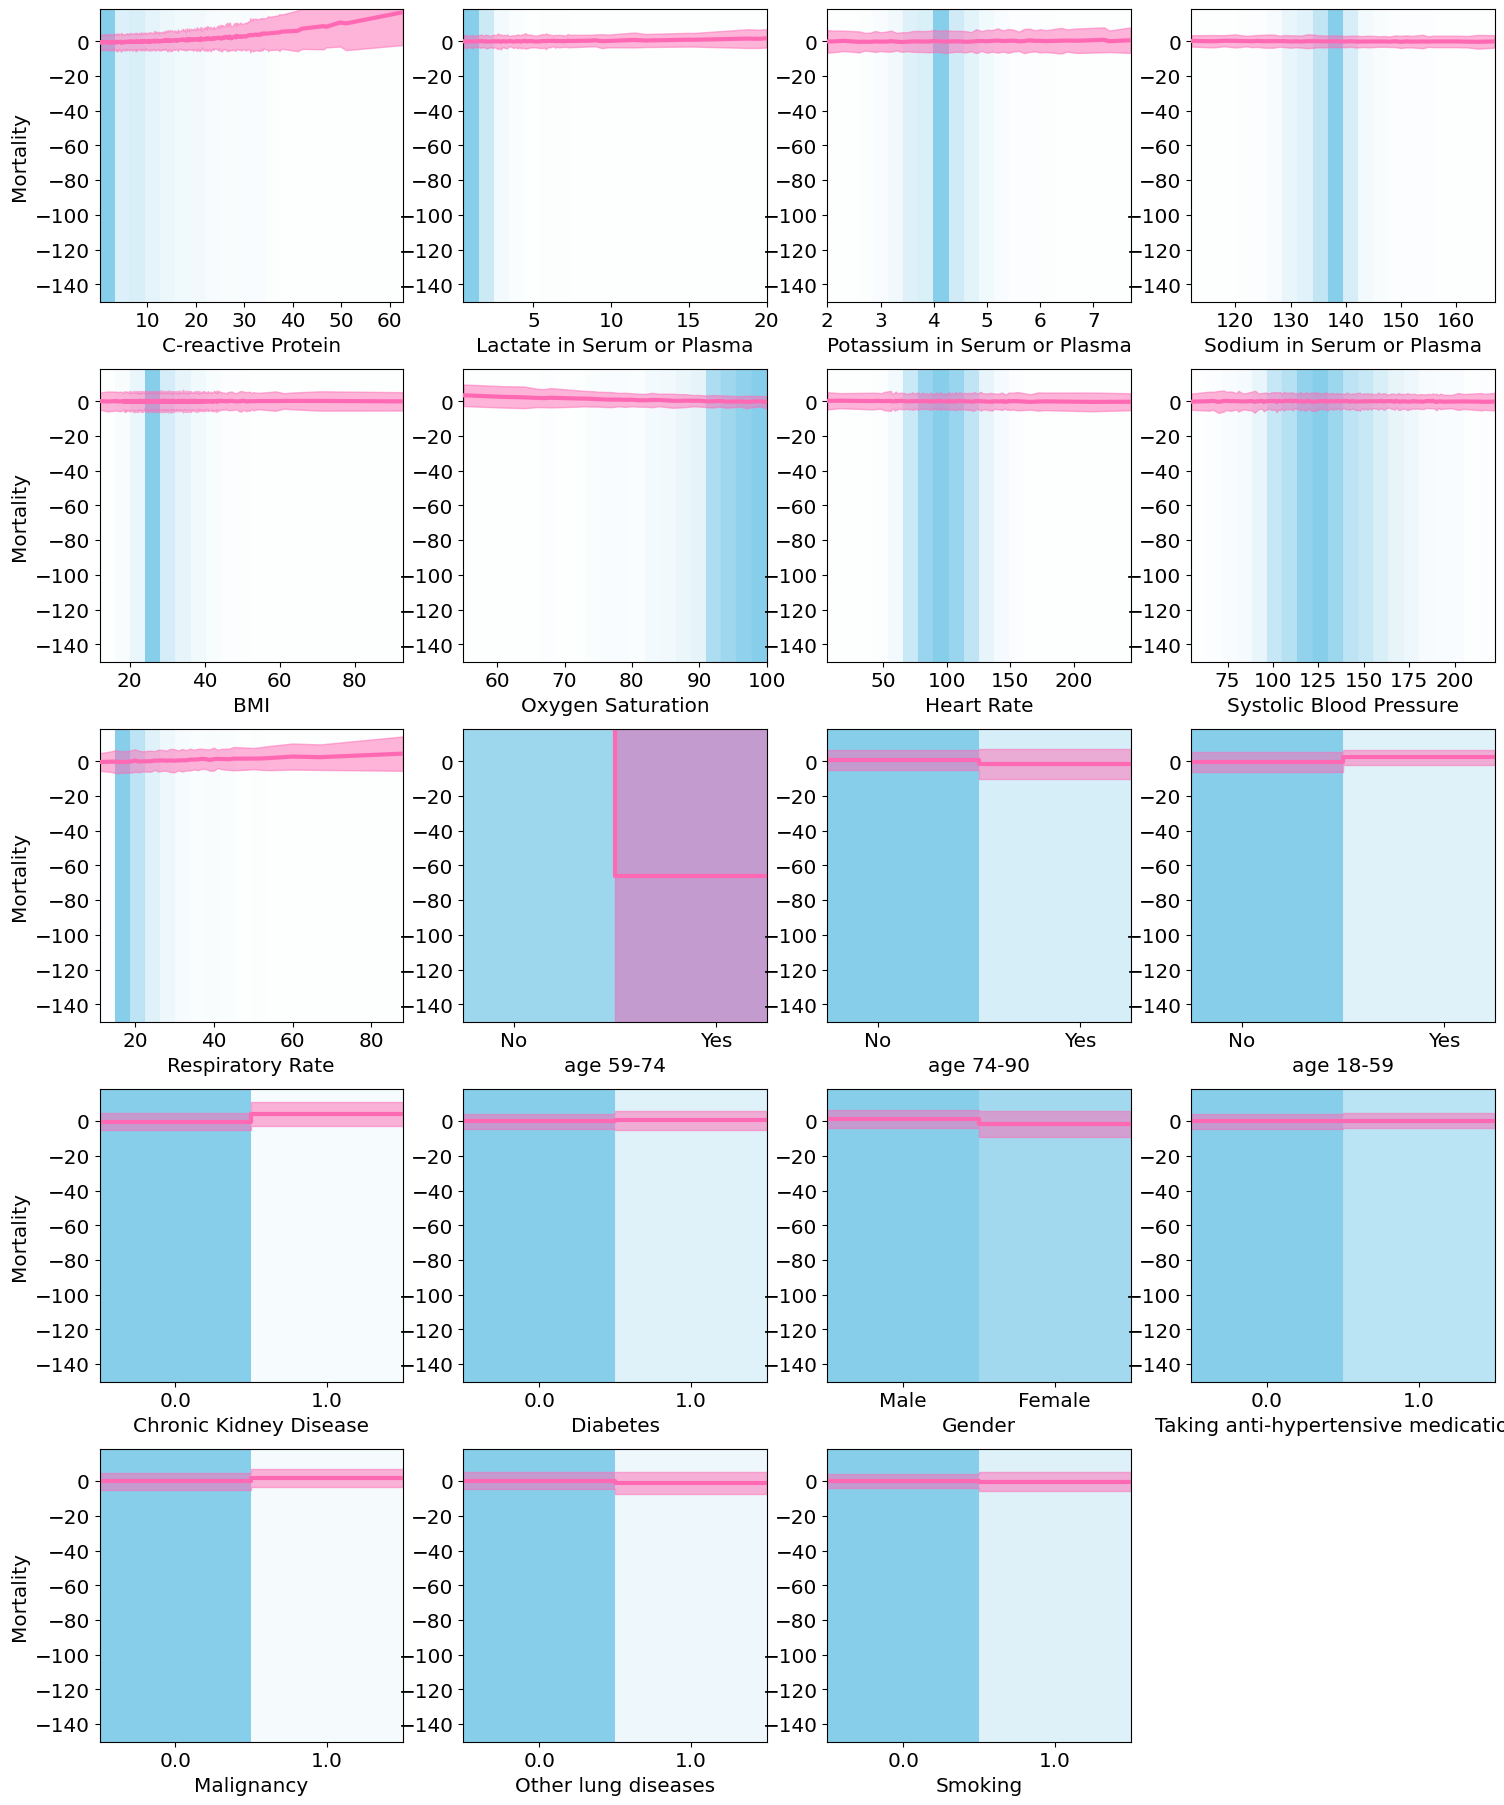

In [42]:
#@title Plot Shape Functions

NUM_COLS =  4
N_BLOCKS =  20

MIN_Y = None
MAX_Y = None


NUM_ROWS = int(np.ceil(NUM_FEATURES / NUM_COLS))
fig = plt.figure(num=None, figsize=(NUM_COLS * 4.5, NUM_ROWS * 4.5),
                 facecolor='w', edgecolor='k')

MIN_Y, MAX_Y = plot_all_hist(avg_hist_data_mean, standard_deviations, NUM_ROWS, NUM_COLS, y_label = "Mortality",
                             min_y=MIN_Y, max_y=MAX_Y, feature_to_use=new_col_names)
shade_by_density_blocks(avg_hist_data, NUM_ROWS, NUM_COLS, n_blocks=N_BLOCKS, feature_to_use=new_col_names)

# This is for plotting individual plots when there are multiple models
"""
for pred in feature_predictions:
  model_hist = {col: pred[0, i] for i, col in enumerate(column_names)}
  plot_all_hist(model_hist, NUM_ROWS, NUM_COLS,
                color_base=[0.3, 0.4, 0.9, 0.2], alpha=0.06,
                linewidth=0.1, min_y=MIN_Y, max_y=MAX_Y, feature_to_use=features)
"""
plt.subplots_adjust(hspace=0.23)
plt.show()


## Ventilation

In [43]:
config = config_ventilated_bnaim

_, _, test_loader, features = dataloaders_img(target_column = config["target"], train_frac = 0.7, val_frac = 0.2, batch_size = config["batch_size"],
                                                  root_dir = root_dir, data_dir = data_dir)


best_trained_model = make_model(config, features.shape[-1])
best_trained_model.to(device)

checkpoint_path = '/content/Bayes_Image_NAM/ckpts and data/checkpoint_ventilated_bnaim.pt'

model_state, _optimizer_state = torch.load(checkpoint_path)
best_trained_model.load_state_dict(model_state)

Global seed set to 0
INFO:lightning:Global seed set to 0


cxr128_autoenc_130M
Model params: 122.59 M


<All keys matched successfully>

In [44]:
feature_predictions = get_feature_predictions(best_trained_model, features, n_samples=100)

In [45]:
NUM_FEATURES = features.shape[1]
SINGLE_FEATURES = np.split(features, NUM_FEATURES, axis=1)
UNIQUE_FEATURES = [np.unique(x, axis=0) for x in SINGLE_FEATURES]

SINGLE_FEATURES_ORIGINAL = {}
UNIQUE_FEATURES_ORIGINAL = {}
for i, col in enumerate(new_col_names):
  try:
    min_val, max_val = col_min_max[col]
    UNIQUE_FEATURES_ORIGINAL[col] = inverse_min_max_scaler(
        UNIQUE_FEATURES[i][:, 0], min_val, max_val)
    SINGLE_FEATURES_ORIGINAL[col] = inverse_min_max_scaler(
        SINGLE_FEATURES[i][:, 0], min_val, max_val)
  except:
    UNIQUE_FEATURES_ORIGINAL[col] = UNIQUE_FEATURES[i][:, 0]
    SINGLE_FEATURES_ORIGINAL[col] = SINGLE_FEATURES[i][:, 0]

In [46]:
avg_hist_data = {col: predictions for col, predictions in zip(new_col_names, feature_predictions)}

In [47]:
ALL_INDICES = {}
for i, col in enumerate(new_col_names):
  x_i = features[:, i]
  ALL_INDICES[col] = np.searchsorted(UNIQUE_FEATURES[i][:, 0], x_i, 'left')

In [49]:
MEAN_PRED = {}
MEAN_STD = {}

n_samples = 100 #adjust this if fails


for col in new_col_names:
    MEAN_PRED[col] = {}
    for j in range(n_samples):
      MEAN_PRED[col][j] = np.mean([avg_hist_data[col][j][i] for i in ALL_INDICES[col]])

print(MEAN_PRED)

{'age.splits: (74,90]': {0: -17.702982, 1: -36.8561, 2: -7.517207, 3: -3.136286, 4: -17.447403, 5: -7.854107, 6: -18.805893, 7: 3.3893719, 8: -30.688515, 9: -11.704714, 10: 9.281434, 11: -34.908134, 12: -17.57297, 13: -21.788132, 14: -33.277924, 15: -20.018454, 16: -1.0546489, 17: -57.50095, 18: -3.3052812, 19: -42.417137, 20: -21.001654, 21: -10.298289, 22: 4.5241394, 23: 8.127502, 24: -5.7854276, 25: -7.2036953, 26: -20.623941, 27: -4.636092, 28: -17.667238, 29: -28.34295, 30: -17.50741, 31: -12.26759, 32: -2.188208, 33: -11.419155, 34: 3.596068, 35: -10.727505, 36: -18.174425, 37: -27.553532, 38: 24.890188, 39: -12.399469, 40: -16.154713, 41: -17.813856, 42: -22.748917, 43: 6.451824, 44: -18.075119, 45: -23.241209, 46: -19.822123, 47: -12.2236395, 48: -3.156025, 49: 13.2217045, 50: -17.436275, 51: 0.18711582, 52: -7.585119, 53: 23.490187, 54: -5.7896557, 55: -18.95475, 56: -15.571736, 57: -17.178082, 58: -8.383732, 59: 2.5580888, 60: -1.058994, 61: -26.804506, 62: 1.3869076, 63: 10.

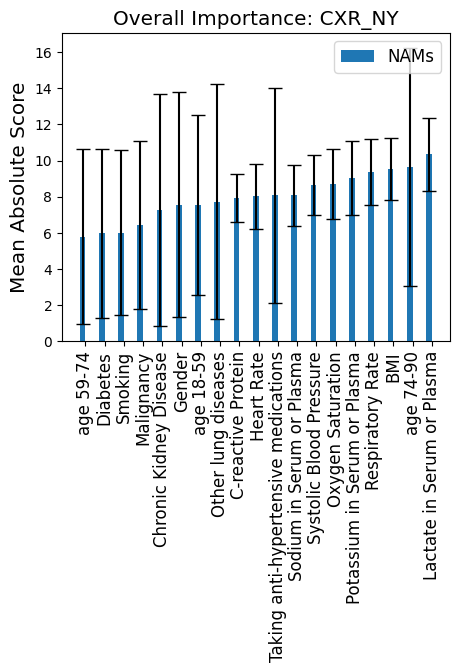

In [50]:
#@title Compute feature importance

x1, x2, std_score = compute_mean_feature_importance(avg_hist_data, n_samples=100) #add bayes and maybe images
cols = [COL_NAMES['CXR_NY'][x] for x in x1]
fig = plot_mean_feature_importance(x1, x2, std_score=std_score)

In [51]:
standard_deviations = {}
avg_hist_data_mean = {}
for key in avg_hist_data.keys():
  avg_hist_data_mean[key] = np.mean(avg_hist_data[key], axis = 0)
  standard_deviations[key] = np.std(avg_hist_data[key], axis = 0)

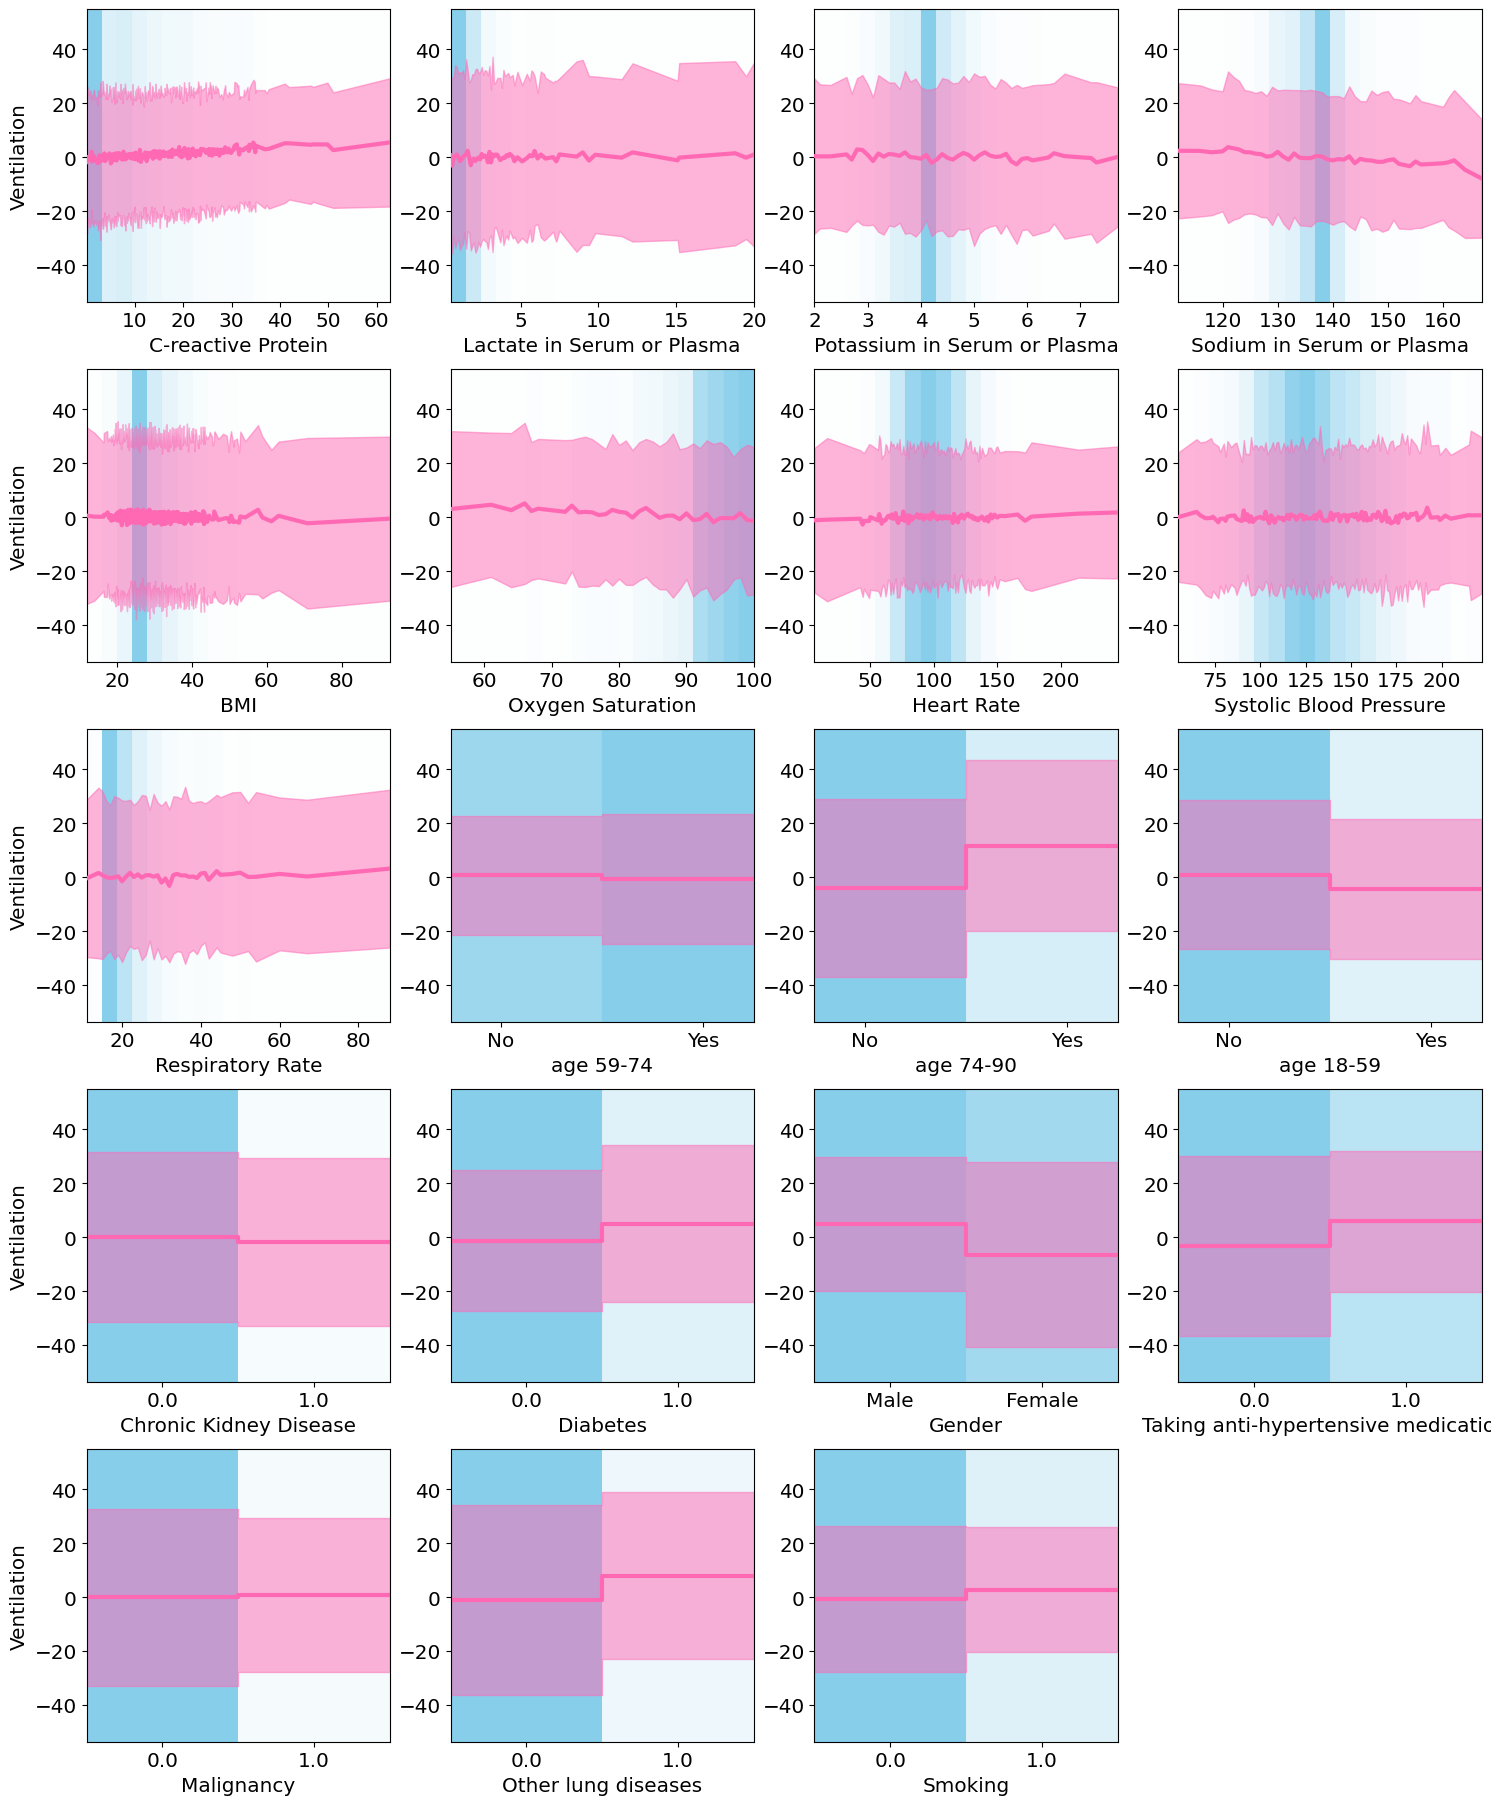

In [52]:
#@title Plot Shape Functions

NUM_COLS =  4
N_BLOCKS =  20

MIN_Y = None
MAX_Y = None


NUM_ROWS = int(np.ceil(NUM_FEATURES / NUM_COLS))
fig = plt.figure(num=None, figsize=(NUM_COLS * 4.5, NUM_ROWS * 4.5),
                 facecolor='w', edgecolor='k')

MIN_Y, MAX_Y = plot_all_hist(avg_hist_data_mean, standard_deviations, NUM_ROWS, NUM_COLS, y_label = "Ventilation", y_scale= 3.0,
                             min_y=MIN_Y, max_y=MAX_Y, feature_to_use=new_col_names)
shade_by_density_blocks(avg_hist_data, NUM_ROWS, NUM_COLS, n_blocks=N_BLOCKS, feature_to_use=new_col_names)

# This is for plotting individual plots when there are multiple models
"""
for pred in feature_predictions:
  model_hist = {col: pred[0, i] for i, col in enumerate(column_names)}
  plot_all_hist(model_hist, NUM_ROWS, NUM_COLS,
                color_base=[0.3, 0.4, 0.9, 0.2], alpha=0.06,
                linewidth=0.1, min_y=MIN_Y, max_y=MAX_Y, feature_to_use=features)
"""
plt.subplots_adjust(hspace=0.23)
plt.show()


## ICU Admission

In [53]:
config = config_icu_bnaim

_, _, test_loader, features = dataloaders_img(target_column = config["target"], train_frac = 0.7, val_frac = 0.2, batch_size = config["batch_size"],
                                                  root_dir = root_dir, data_dir = data_dir)


best_trained_model = make_model(config, features.shape[-1])
best_trained_model.to(device)

checkpoint_path = '/content/Bayes_Image_NAM/ckpts and data/checkpoint_icu_bnaim.pt'

model_state, _optimizer_state = torch.load(checkpoint_path)
best_trained_model.load_state_dict(model_state)

Global seed set to 0
INFO:lightning:Global seed set to 0


cxr128_autoenc_130M
Model params: 122.59 M


<All keys matched successfully>

In [54]:
feature_predictions = get_feature_predictions(best_trained_model, features, n_samples=100)

In [55]:
NUM_FEATURES = features.shape[1]
SINGLE_FEATURES = np.split(features, NUM_FEATURES, axis=1)
UNIQUE_FEATURES = [np.unique(x, axis=0) for x in SINGLE_FEATURES]

SINGLE_FEATURES_ORIGINAL = {}
UNIQUE_FEATURES_ORIGINAL = {}
for i, col in enumerate(new_col_names):
  try:
    min_val, max_val = col_min_max[col]
    UNIQUE_FEATURES_ORIGINAL[col] = inverse_min_max_scaler(
        UNIQUE_FEATURES[i][:, 0], min_val, max_val)
    SINGLE_FEATURES_ORIGINAL[col] = inverse_min_max_scaler(
        SINGLE_FEATURES[i][:, 0], min_val, max_val)
  except:
    UNIQUE_FEATURES_ORIGINAL[col] = UNIQUE_FEATURES[i][:, 0]
    SINGLE_FEATURES_ORIGINAL[col] = SINGLE_FEATURES[i][:, 0]

In [56]:
avg_hist_data = {col: predictions for col, predictions in zip(new_col_names, feature_predictions)}

In [57]:
ALL_INDICES = {}
for i, col in enumerate(new_col_names):
  x_i = features[:, i]
  ALL_INDICES[col] = np.searchsorted(UNIQUE_FEATURES[i][:, 0], x_i, 'left')

In [58]:
MEAN_PRED = {}
MEAN_STD = {}

n_samples = 100 #adjust this if fails


for col in new_col_names:
    MEAN_PRED[col] = {}
    for j in range(n_samples):
      MEAN_PRED[col][j] = np.mean([avg_hist_data[col][j][i] for i in ALL_INDICES[col]])

print(MEAN_PRED)

{'age.splits: (74,90]': {0: -17.047432, 1: -14.477674, 2: -2.1653626, 3: -9.754877, 4: -7.3779764, 5: -13.147013, 6: 4.921668, 7: -8.183417, 8: -13.455534, 9: -0.5534124, 10: -7.7064705, 11: -18.159487, 12: -0.16033323, 13: -13.223303, 14: -3.672618, 15: -14.825076, 16: -3.24717, 17: -12.246363, 18: -1.8394032, 19: -21.74142, 20: -11.927791, 21: 1.0574291, 22: 2.429479, 23: -6.7149134, 24: -9.717561, 25: -3.4379597, 26: -15.24776, 27: -22.953072, 28: -16.147697, 29: -12.396013, 30: -9.200732, 31: -11.734953, 32: -9.733584, 33: -6.207755, 34: -1.8313746, 35: -10.691936, 36: -9.020556, 37: -10.272135, 38: 8.968987, 39: -6.5438356, 40: -2.346079, 41: -9.948339, 42: -5.1426945, 43: 3.7526515, 44: -7.104154, 45: -12.022345, 46: -8.298317, 47: -8.859961, 48: -7.49485, 49: 11.425498, 50: -20.111797, 51: -5.9053283, 52: -1.4950001, 53: -9.775017, 54: -5.813426, 55: -12.279434, 56: -2.553187, 57: -11.832379, 58: -6.615253, 59: -3.9688578, 60: -8.868873, 61: -0.9885382, 62: 0.58261317, 63: -3.56

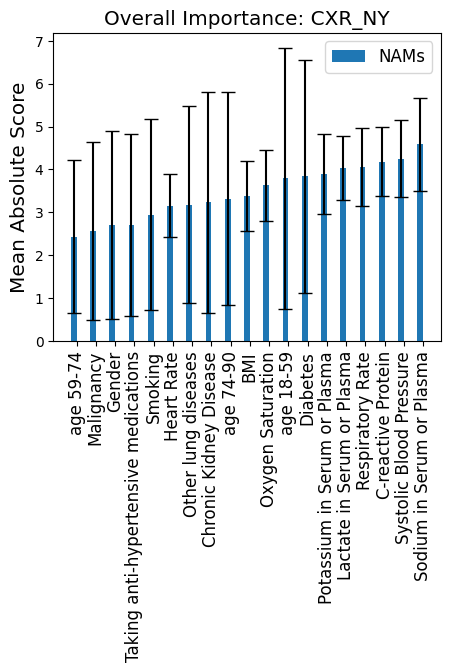

In [61]:
#@title Compute feature importance

x1, x2, std_score = compute_mean_feature_importance(avg_hist_data, n_samples=100) #add bayes and maybe images
cols = [COL_NAMES['CXR_NY'][x] for x in x1]
fig = plot_mean_feature_importance(x1, x2, std_score=std_score)

In [59]:
standard_deviations = {}
avg_hist_data_mean = {}
for key in avg_hist_data.keys():
  avg_hist_data_mean[key] = np.mean(avg_hist_data[key], axis = 0)
  standard_deviations[key] = np.std(avg_hist_data[key], axis = 0)

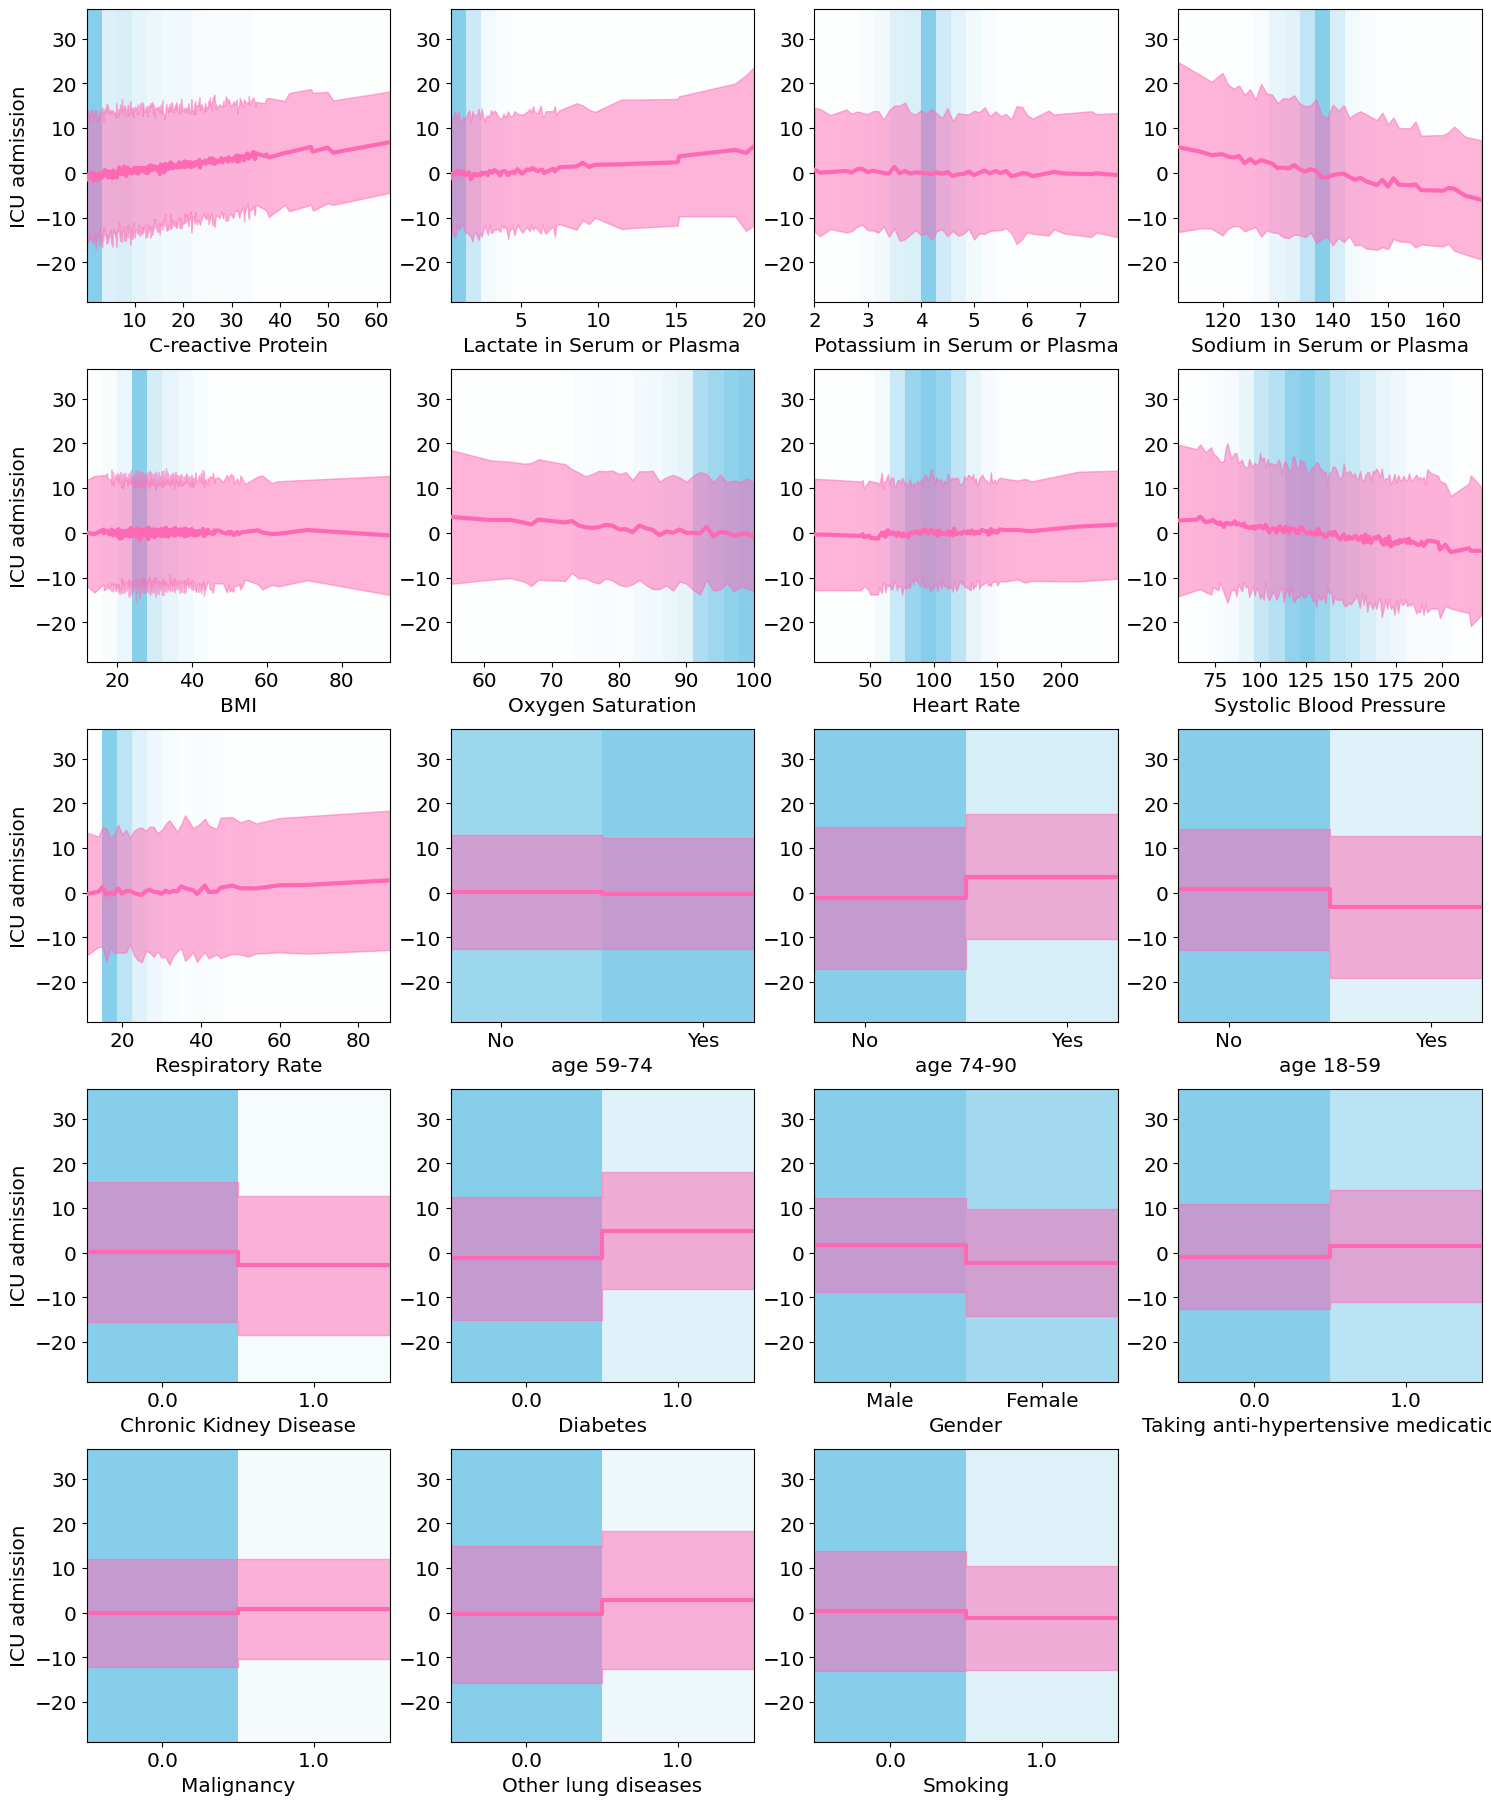

In [60]:
#@title Plot Shape Functions

NUM_COLS =  4
N_BLOCKS =  20

MIN_Y = None
MAX_Y = None


NUM_ROWS = int(np.ceil(NUM_FEATURES / NUM_COLS))
fig = plt.figure(num=None, figsize=(NUM_COLS * 4.5, NUM_ROWS * 4.5),
                 facecolor='w', edgecolor='k')

MIN_Y, MAX_Y = plot_all_hist(avg_hist_data_mean, standard_deviations, NUM_ROWS, NUM_COLS, y_label = "ICU admission", y_scale= 3.0,
                             min_y=MIN_Y, max_y=MAX_Y, feature_to_use=new_col_names)
shade_by_density_blocks(avg_hist_data, NUM_ROWS, NUM_COLS, n_blocks=N_BLOCKS, feature_to_use=new_col_names)

# This is for plotting individual plots when there are multiple models
"""
for pred in feature_predictions:
  model_hist = {col: pred[0, i] for i, col in enumerate(column_names)}
  plot_all_hist(model_hist, NUM_ROWS, NUM_COLS,
                color_base=[0.3, 0.4, 0.9, 0.2], alpha=0.06,
                linewidth=0.1, min_y=MIN_Y, max_y=MAX_Y, feature_to_use=features)
"""
plt.subplots_adjust(hspace=0.23)
plt.show()


## Interpolation

In [62]:
_, _, test_loader, features = dataloaders_img(target_column = 'is_icu', train_frac = 0.7, val_frac = 0.2, batch_size = 32,
                                                  root_dir = root_dir, data_dir = data_dir)

In [63]:
img_zero = next(iter(test_loader))[0][0]
img_one = next(iter(test_loader))[0][26]

In [66]:
batch = torch.stack([
    img_zero,
    img_one,
])

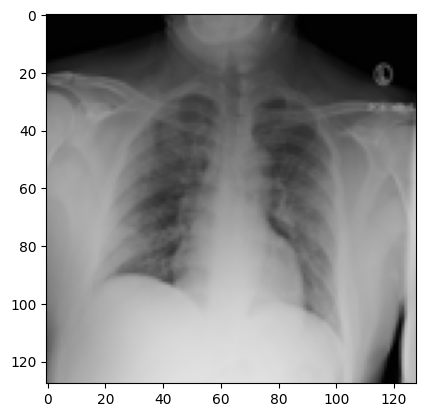

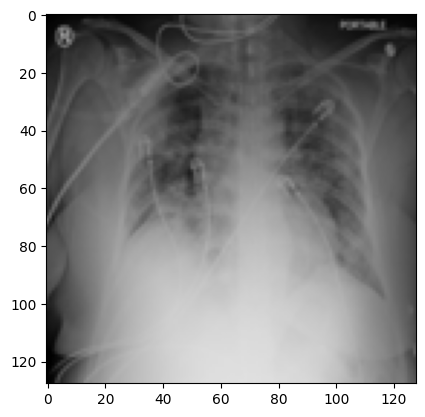

In [67]:
plt.imshow(batch[0].permute([1, 2, 0]) / 2 + 0.5)
plt.show()
plt.imshow(batch[1].permute([1, 2, 0]) / 2 + 0.5)

In [68]:
cond = pretrained_encoder.encode(batch.to(device)) #encode to z_sem1 and z_sem2
xT = pretrained_encoder.encode_stochastic(batch.to(device), cond, T=250) #encode to xt_1 and xt_2

In [69]:
n_interpolation_steps = 6
alpha = torch.tensor(np.linspace(0, 1, n_interpolation_steps, dtype=np.float32)).to(cond.device) #t
intp = cond[0][None] * (1 - alpha[:, None]) + cond[1][None] * alpha[:, None] #linear interpolation z_sem1, z_sem2

def cos(a, b):
    a = a.view(-1)
    b = b.view(-1)
    a = F.normalize(a, dim=0)
    b = F.normalize(b, dim=0)
    return (a * b).sum()

theta = torch.arccos(cos(xT[0], xT[1]))
x_shape = xT[0].shape
intp_x = (torch.sin((1 - alpha[:, None]) * theta) * xT[0].flatten(0, 2)[None] + torch.sin(alpha[:, None] * theta) * xT[1].flatten(0, 2)[None]) / torch.sin(theta) #spherical interpolation for xt_1 and xt_2
intp_x = intp_x.view(-1, *x_shape)

pred = pretrained_encoder.render(intp_x, intp, T=200) # decode

In [70]:
n_interpolation_steps_pred = 100
alpha_pred = torch.tensor(np.linspace(0, 1, n_interpolation_steps_pred, dtype=np.float32)).to(cond.device) # linear interpolation with more steps of z_sem
intp_pred = cond[0][None] * (1 - alpha_pred[:, None]) + cond[1][None] * alpha_pred[:, None]

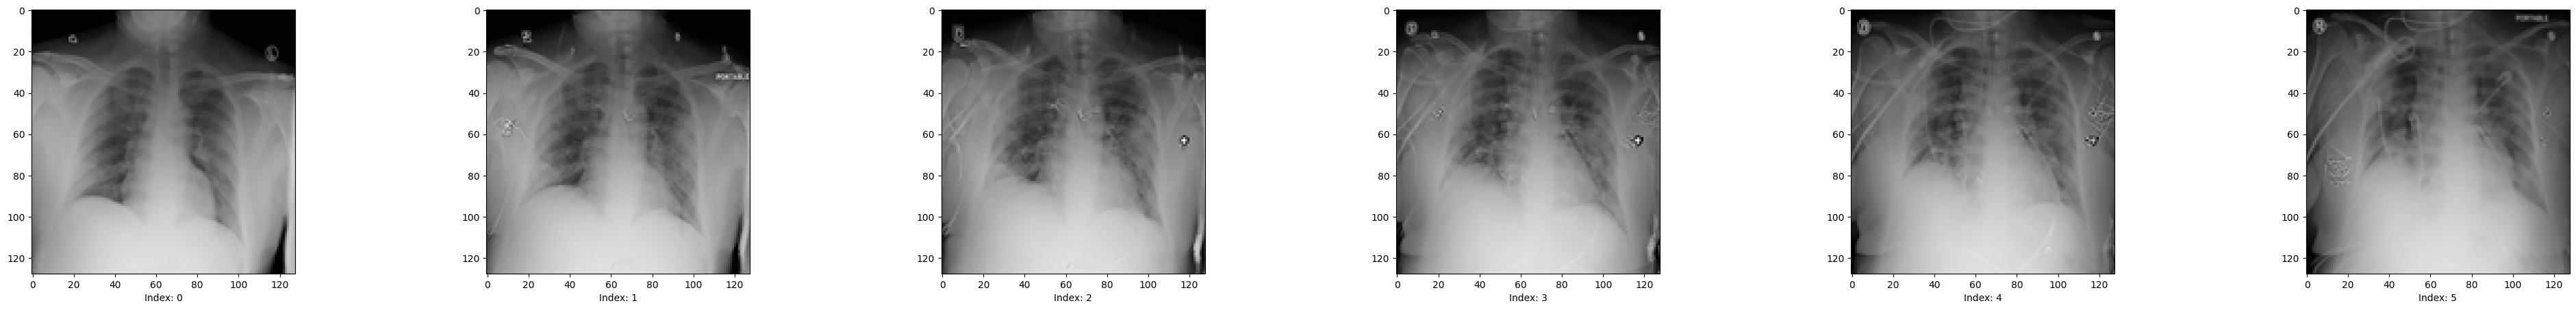

In [71]:
fig, ax = plt.subplots(1, n_interpolation_steps, figsize=(5*10, 5))
for i in range(len(alpha)):
    ax[i].imshow(pred[i].permute(1, 2, 0).cpu())
    ax[i].set_xlabel("Index: {}".format(i))
plt.show()

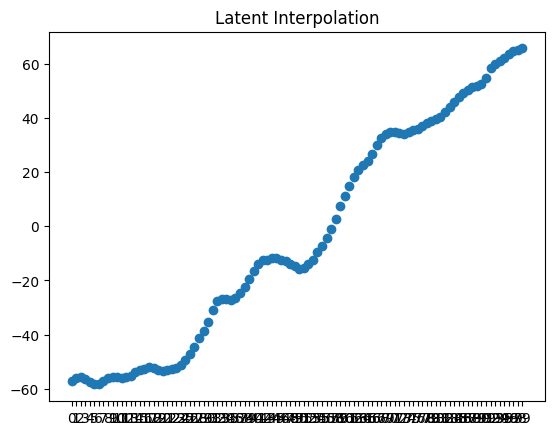

In [72]:
plt.scatter(range(len(alpha_pred)), best_trained_model.bayes_mlp(intp_pred)[0].detach().cpu().numpy()) #model prediction
plt.xticks(range(len(alpha_pred)))
plt.title("Latent Interpolation")
plt.show()

In [73]:
def find_nearest_multiples(x):
    """Find the nearest greater and smaller multiples of 1000 to a given float."""

    greater_multiple = (int(x)//500 + 1) * 500
    smaller_multiple = (int(x)//500) * 500

    return greater_multiple, smaller_multiple

In [74]:
find_nearest_multiples(7777)

(8000, 7500)

In [75]:
n_interpolation_steps_pred = 100*len(alpha)
alpha_pred = torch.tensor(np.linspace(0, 1, n_interpolation_steps_pred, dtype=np.float32)).to(cond.device)
intp_pred = cond[0][None] * (1 - alpha_pred[:, None]) + cond[1][None] * alpha_pred[:, None]

In [76]:
list(range(10))[::3]

[0, 3, 6, 9]

In [77]:
unstandardize_and_exp_targets = lambda x: x - np.mean(x.numpy())

<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:45: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_3919/2178722243.py:45: SyntaxWarning: invalid escape sequence '\p'
  label="$\pm$2$\sigma$ Uncertainty")
/tmp/ipykernel_3919/2178722243.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_yticklabels(['{:,.0f}'.format(y) for y in yticks], fontsize=20)


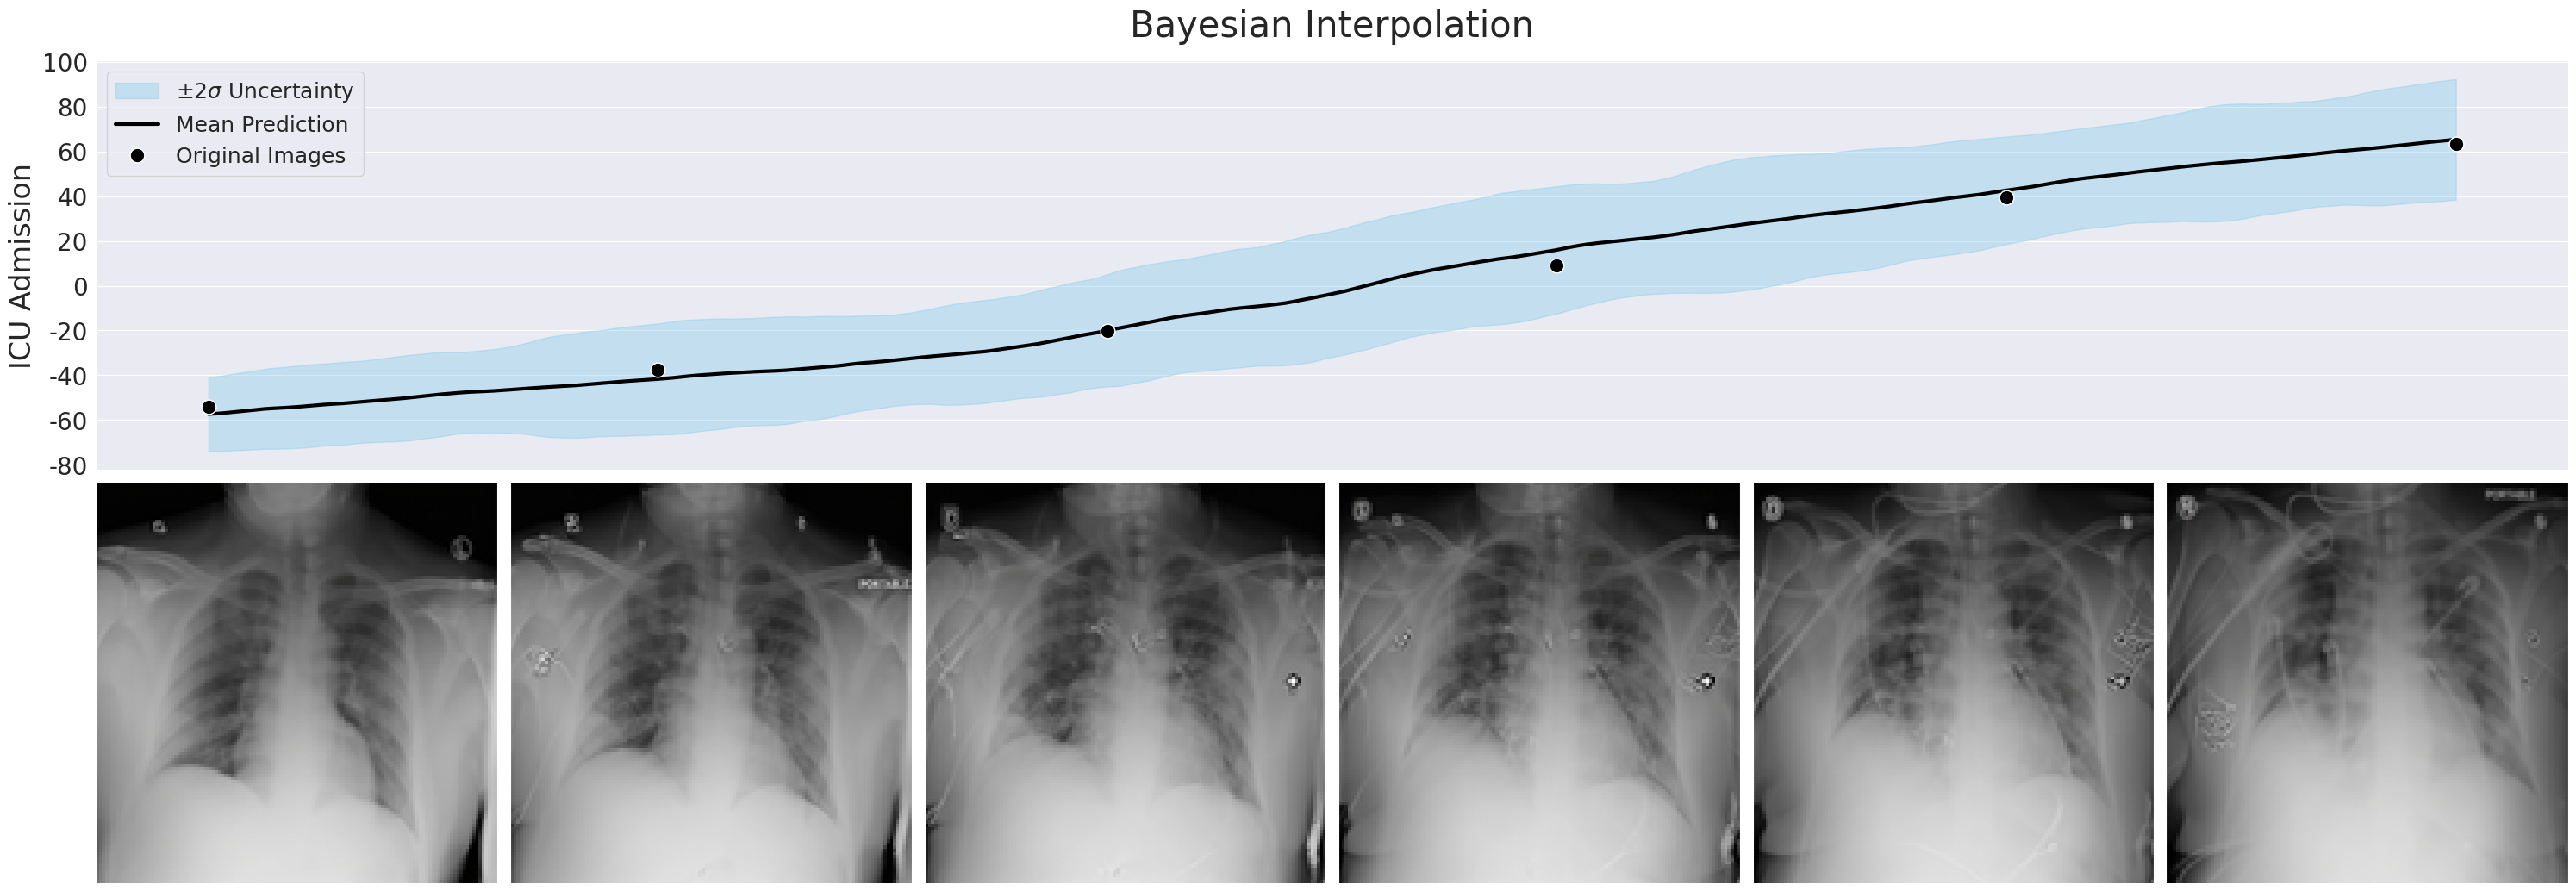

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

with sns.axes_style('darkgrid'):
    fig = plt.figure(figsize=(30, 10.5))
    gs = fig.add_gridspec(2, n_interpolation_steps, height_ratios=[1, 1])

    output_intp_pred = []
    output_intp = []

    # Sample:
    for _ in range(10):
        out_intp_pred, _ = best_trained_model.bayes_mlp(intp_pred)
        out_intp, _ = best_trained_model.bayes_mlp(intp)
        output_intp_pred.append(out_intp_pred)
        output_intp.append(out_intp)

    output_intp_pred = torch.stack(output_intp_pred)
    mean_pred_intp_pred = torch.mean(output_intp_pred, dim=0)
    mean_intp_pred = mean_pred_intp_pred - torch.mean(mean_pred_intp_pred)
    mean_outputs_intp_pred = mean_intp_pred.detach().cpu().numpy().squeeze()

    output_intp = torch.stack(output_intp)
    mean_pred_intp = torch.mean(output_intp, dim=0)
    mean_intp = mean_pred_intp - torch.mean(mean_pred_intp)
    mean_outputs_intp = mean_intp.detach().cpu().numpy().squeeze()

    # Calculate standard deviation and error bounds
    std_intp_pred = torch.sqrt(torch.var(output_intp_pred, dim=0))
    standard_variations = std_intp_pred.detach().cpu().numpy().squeeze()

    plus_error = mean_outputs_intp_pred + 2 * standard_variations
    minus_error = mean_outputs_intp_pred - 2 * standard_variations

    # 1. Main Prediction Plot
    ax3 = fig.add_subplot(gs[0, :])
    x_range = np.arange(len(intp_pred))

    # Add the Uncertainty
    ax3.fill_between(x_range, minus_error, plus_error,
                     color="skyblue",
                     alpha=0.4,
                     label="$\pm$2$\sigma$ Uncertainty")

    # Add the Mean Line
    ax3.plot(x_range, mean_outputs_intp_pred, color="black", linewidth=3, label="Mean Prediction")

    x_red_plot = np.linspace(0, len(intp_pred)-1, len(alpha))
    ax3.plot(x_red_plot, mean_outputs_intp, 'o', markersize=12, c="black", markeredgecolor="white", label="Original Images")

    ax3.set_ylabel('ICU Admission', fontsize=24)
    ax3.set_title("Bayesian Interpolation", fontsize=30, pad=20)

    # Legend
    ax3.legend(loc='upper left', fontsize=18, frameon=True)

    ax3.get_yaxis().set_major_locator(plt.MaxNLocator(integer=True))
    yticks = ax3.get_yticks()
    ax3.set_yticklabels(['{:,.0f}'.format(y) for y in yticks], fontsize=20)

    # Remove x-axis ticks
    ax3.set_xticks([])

    # 2. Plot the Images
    for i in range(len(alpha)):
        axi = fig.add_subplot(gs[1, i])
        axi.imshow(pred[i].permute(1, 2, 0).cpu())
        axi.set_xticks([])
        axi.set_yticks([])

        axi.set_xlabel("")

    plt.tight_layout()
    plt.show()